/tmp/ipykernel_2989729/2274097354.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['matrix', 'test_config', 'config'], group_keys=False).apply(calc_speedup)


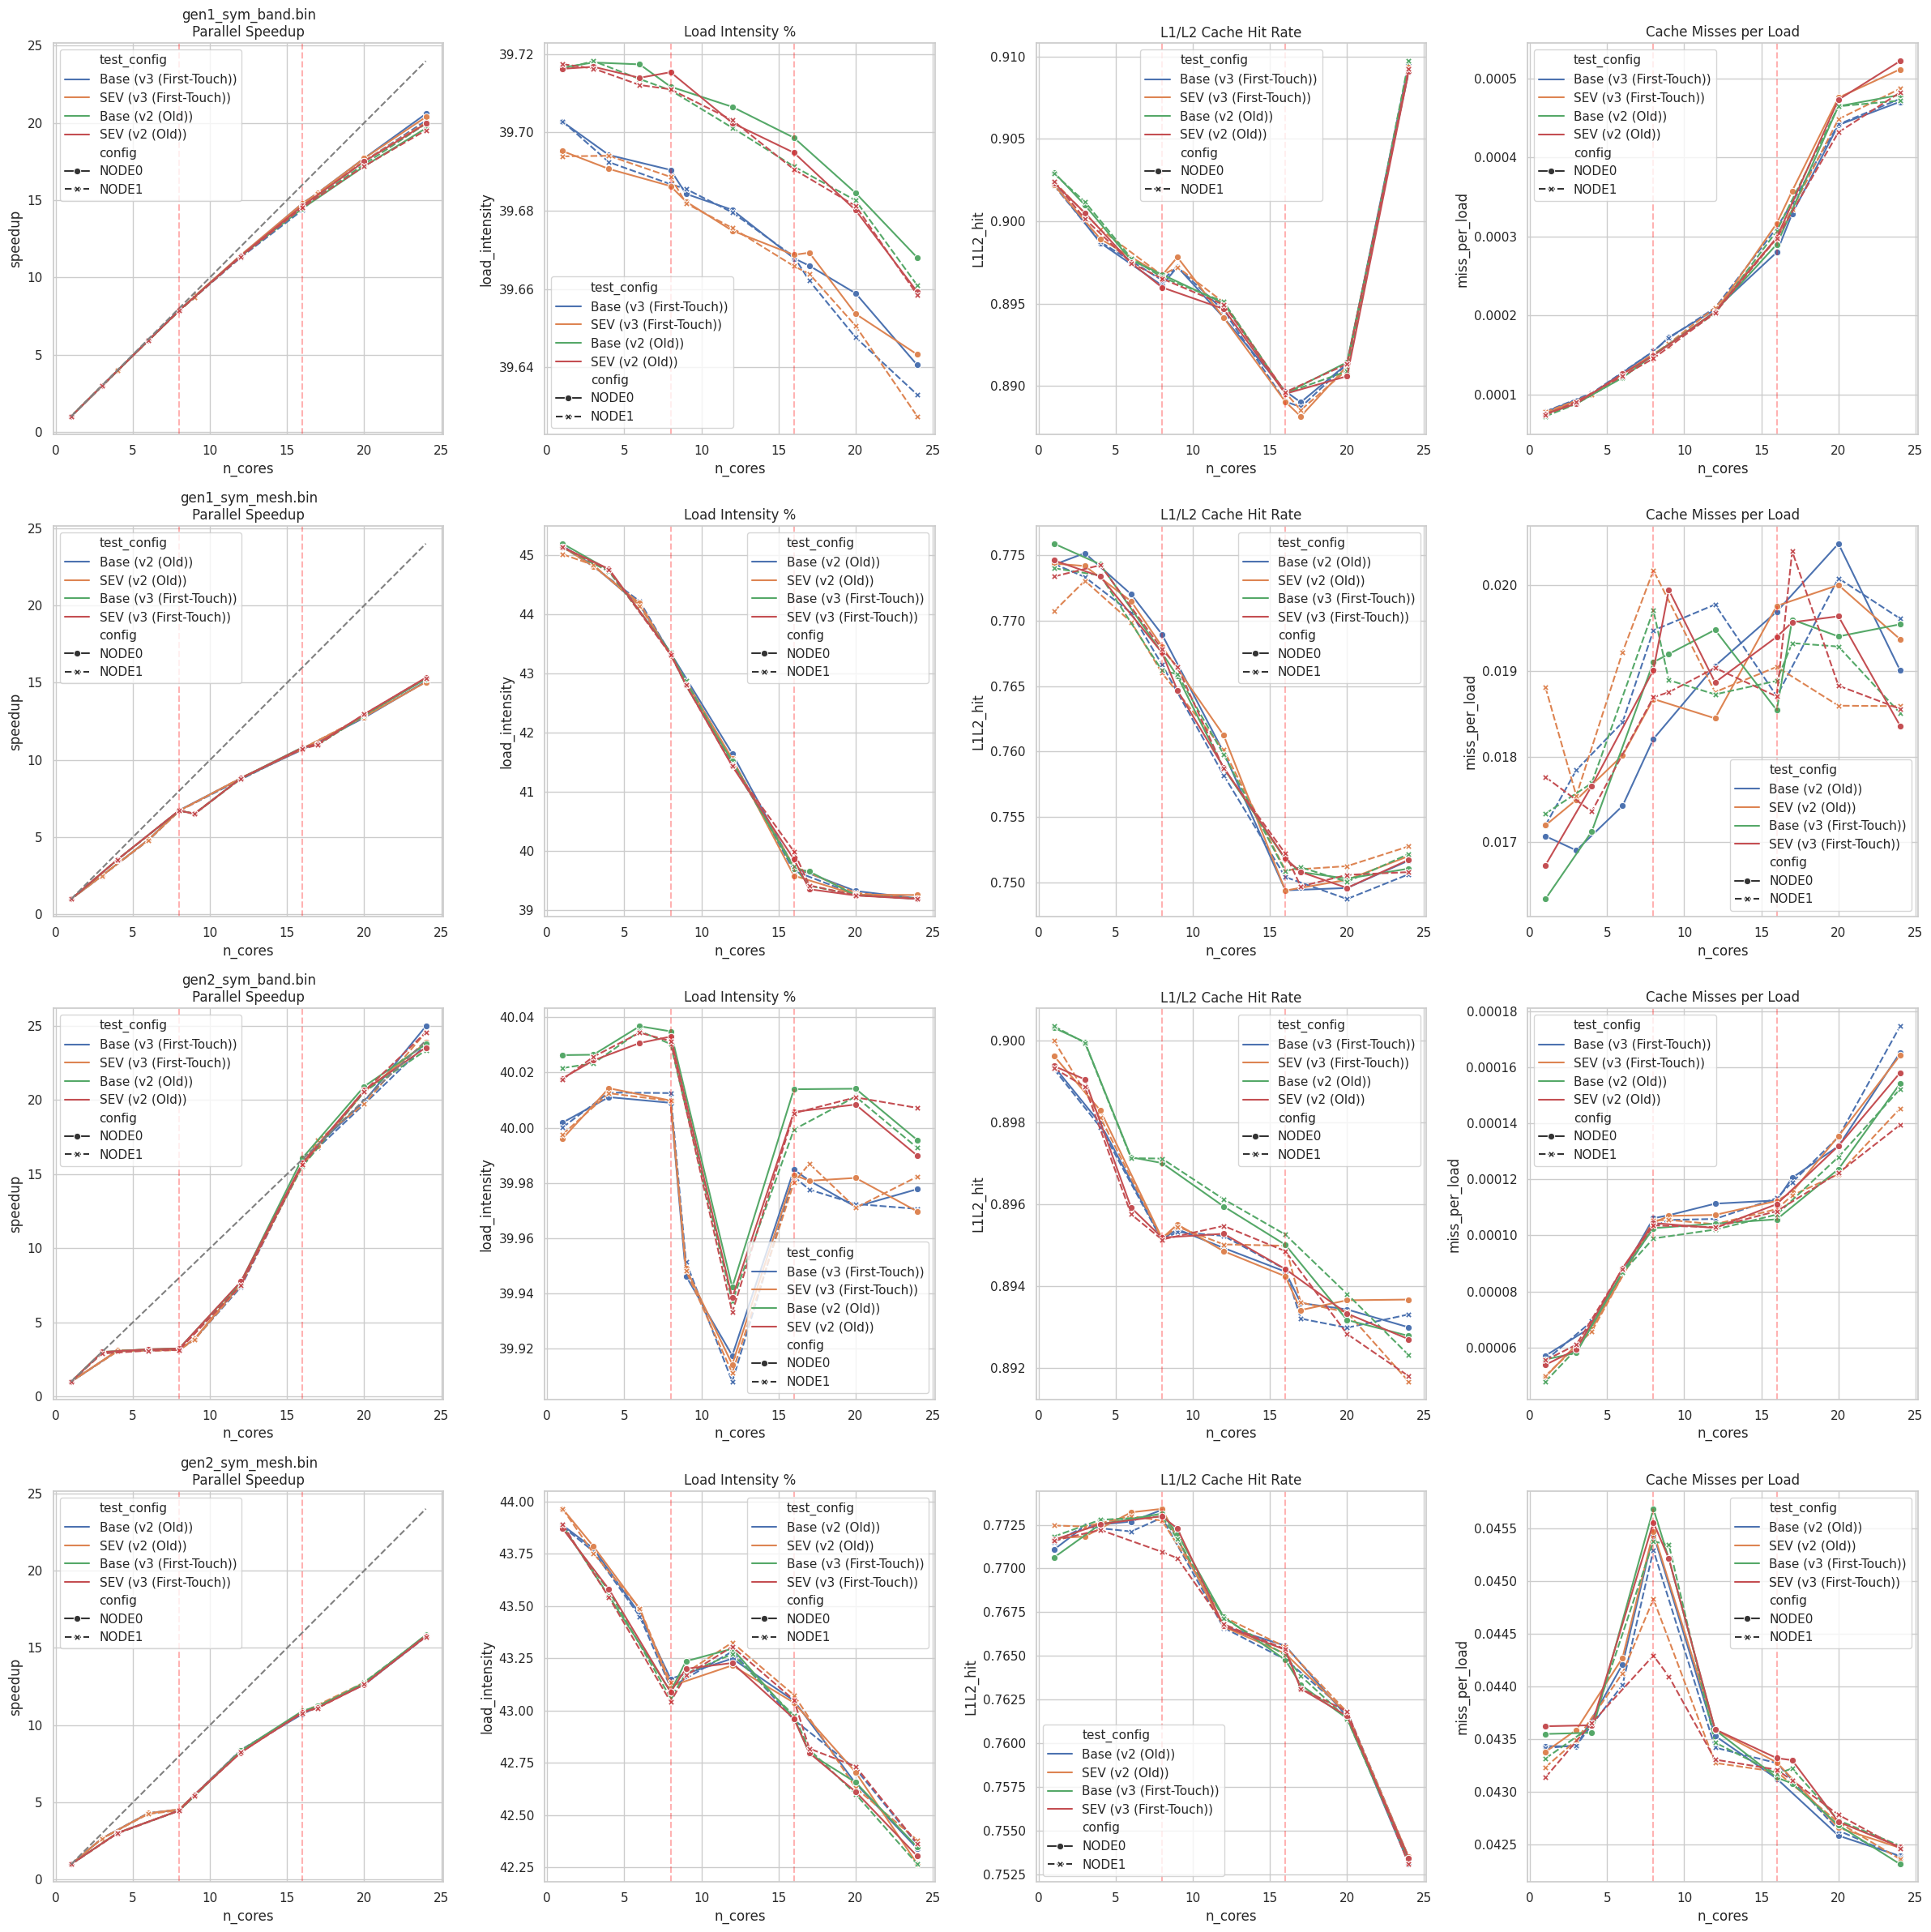

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def load_and_label(path, env, version):
    return pd.read_csv(path).assign(env=env, version=version)

df2_base = load_and_label('results/base2.csv', 'Base', 'v2 (Old)')
df2_sev  = load_and_label('results/sev2.csv', 'SEV', 'v2 (Old)')
df3_base = load_and_label('results/base3.csv', 'Base', 'v3 (First-Touch)')
df3_sev  = load_and_label('results/sev3.csv', 'SEV', 'v3 (First-Touch)')

df = pd.concat([df2_base, df2_sev, df3_base, df3_sev])
df['matrix'] = df['matrix_path'].apply(lambda x: "_".join(x.split('/')[-2:]))
df['test_config'] = df['env'] + " (" + df['version'] + ")"

df['load_intensity'] = (df['perf_l1_loads'] / df['perf_instructions']) * 100
df['miss_per_load'] = df['perf_cache_misses'] / df['perf_l1_loads']
df['L1L2_hit'] = 1 - (df['perf_cache_misses'] + df['perf_cache_refs']) / df['perf_l1_loads']

def calc_speedup(group):
    base_val = group[group['n_cores'] == 1]['gflops'].median()
    group['speedup'] = group['gflops'] / base_val
    return group

df = df.groupby(['matrix', 'test_config', 'config'], group_keys=False).apply(calc_speedup)

sns.set_theme(style="whitegrid")
matrices = sorted(df['matrix'].unique())

fig, axes = plt.subplots(len(matrices), 4, figsize=(24, 6 * len(matrices)), squeeze=False)

for i, m_name in enumerate(matrices):
    m_data = df[df['matrix'] == m_name]
    
    p_args = {'data': m_data, 'x': 'n_cores', 'hue': 'test_config', 'style': 'config', 
              'markers': True, 'estimator': np.median, 'errorbar': None}

    sns.lineplot(ax=axes[i, 0], y='speedup', **p_args)
    max_cores = m_data['n_cores'].max()
    axes[i, 0].plot([1, max_cores], [1, max_cores], color='gray', linestyle='--')
    axes[i, 0].set_title(f"{m_name}\nParallel Speedup")
    
    sns.lineplot(ax=axes[i, 1], y='load_intensity', **p_args)
    axes[i, 1].set_title(f"Load Intensity %")

    sns.lineplot(ax=axes[i, 2], y='L1L2_hit', **p_args)
    axes[i, 2].set_title(f"L1/L2 Cache Hit Rate")

    sns.lineplot(ax=axes[i, 3], y='miss_per_load', **p_args)
    axes[i, 3].set_title(f"Cache Misses per Load")
    
    for j in range(4):
        axes[i, j].axvline(x=8, color='red', linestyle='--', alpha=0.3)
        axes[i, j].axvline(x=16, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

pivot_df = df.groupby(['matrix', 'env', 'version'])['gflops'].median().unstack(['env', 'version'])

summary = pd.DataFrame(index=pivot_df.index)

summary['Base_v3_vs_v2_%'] = ((pivot_df[('Base', 'v3 (First-Touch)')] / 
                                pivot_df[('Base', 'v2 (Old)')]) - 1) * 100

summary['SEV_v3_vs_v2_%'] = ((pivot_df[('SEV', 'v3 (First-Touch)')] / 
                               pivot_df[('SEV', 'v2 (Old)')]) - 1) * 100

summary['SEV_Penalty_v3_%'] = ((pivot_df[('SEV', 'v3 (First-Touch)')] / 
                                 pivot_df[('Base', 'v3 (First-Touch)')]) - 1) * 100

pd.options.display.float_format = '{:,.2f}%'.format
print("\n--- Zusammenfassung der Performance-Unterschiede (Median über alle Kerne) ---")
print(summary)



--- Zusammenfassung der Performance-Unterschiede (Median über alle Kerne) ---
                   Base_v3_vs_v2_%  SEV_v3_vs_v2_%  SEV_Penalty_v3_%
matrix                                                              
gen1_sym_band.bin           18.33%          20.98%             1.23%
gen1_sym_mesh.bin           16.01%          14.30%            -0.18%
gen2_sym_band.bin           39.76%          42.03%             0.33%
gen2_sym_mesh.bin           28.67%          29.53%            -0.31%
